In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
%run "/content/gdrive/MyDrive/PalmWatch/Colab Notebooks/ImportFilesAndFunctions.ipynb"

Mounted at /content/gdrive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 36.4 MB/s eta 0:00:00


INFO:lightning_fabric.utilities.seed:Seed set to 42


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
All imports successful!


In [ ]:
# Loading data
data = pd.read_csv("/content/gdrive/MyDrive/PalmWatch/data/hex_deforestation_forecast_oldversion.csv")
data.head(10)

,hex_id,year,province,lat,lon,hex_area_km2,forest_2000_ha,forest_2000_frac,target_total_5yr,target_palm_5yr,defor_frac,degr_frac,remaining_frac_baseline,remaining_frac_hex,remaining_forest_ha,nbr_r1_defor_frac,nbr_r2_defor_frac,nbr_r1_remaining_frac_baseline
0,86642c96fffffff,2000,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,0.075724,0.0,0.000000,0.000000,1.000000,0.464663,2009.95,0.000000,NaN,1.000000
1,86642c96fffffff,2001,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,0.055538,0.0,0.032801,0.027606,0.967199,0.449421,1944.02,0.006728,NaN,0.993272
2,86642c96fffffff,2002,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,0.046985,0.0,0.021762,0.024175,0.945437,0.439309,1900.28,0.008174,NaN,0.985098
3,86642c96fffffff,2003,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,0.048393,0.0,0.001903,0.000973,0.943534,0.438425,1896.46,0.000895,NaN,0.984203
4,86642c96fffffff,2004,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,0.046477,0.0,0.011296,0.007714,0.932238,0.433177,1873.75,0.004071,NaN,0.980132
5,86642c96fffffff,2005,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,0.043050,0.0,0.007962,0.006214,0.924276,0.429477,1857.75,0.002916,NaN,0.977216
6,86642c96fffffff,2006,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,0.038974,0.0,0.010793,0.007286,0.913483,0.424462,1836.06,0.002757,NaN,0.974459
7,86642c96fffffff,2007,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,0.030490,0.0,0.012467,0.012890,0.901016,0.418669,1811.00,0.002668,NaN,0.971791
8,86642c96fffffff,2008,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,0.028132,0.0,0.003142,0.002522,0.897874,0.417209,1804.68,0.002021,NaN,0.969770
9,86642c96fffffff,2009,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,0.025524,0.0,0.008963,0.009247,0.888911,0.413044,1786.67,0.003951,NaN,0.965819


In [ ]:
# Grouping by providence and year
deforest_prov_t = data.groupby(["province", "year"])[["remaining_frac_baseline", "defor_frac", "degr_frac"]].mean().reset_index()
deforest_prov_t

,province,year,remaining_frac_baseline,defor_frac,degr_frac
0,Aceh,2000,1.000000,0.000000,0.000000
1,Aceh,2001,0.989450,0.010550,0.010663
2,Aceh,2002,0.981686,0.007765,0.007863
3,Aceh,2003,0.977875,0.003810,0.004135
4,Aceh,2004,0.970964,0.006912,0.004632
...,...,...,...,...,...
147,SumateraUtara,2014,0.728190,0.014955,0.009137
148,SumateraUtara,2015,0.717714,0.010477,0.006325
149,SumateraUtara,2016,0.709952,0.007762,0.005633
150,SumateraUtara,2017,0.703559,0.006392,0.005659


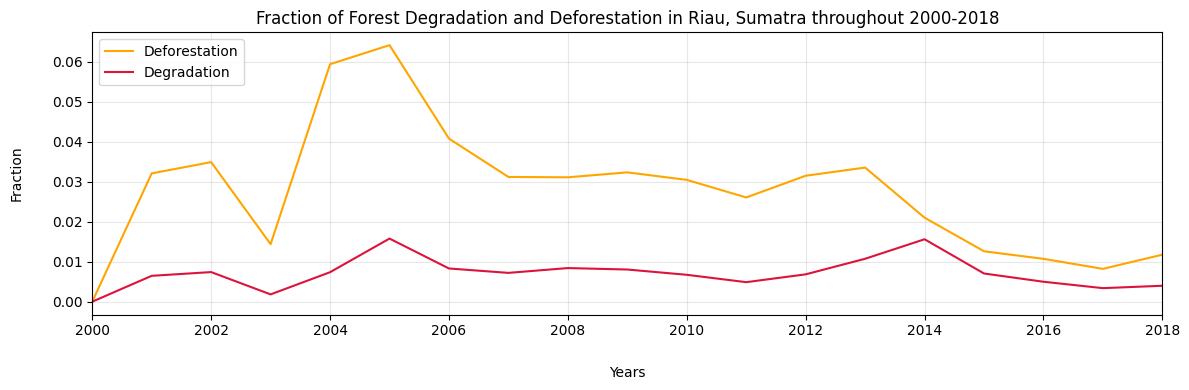

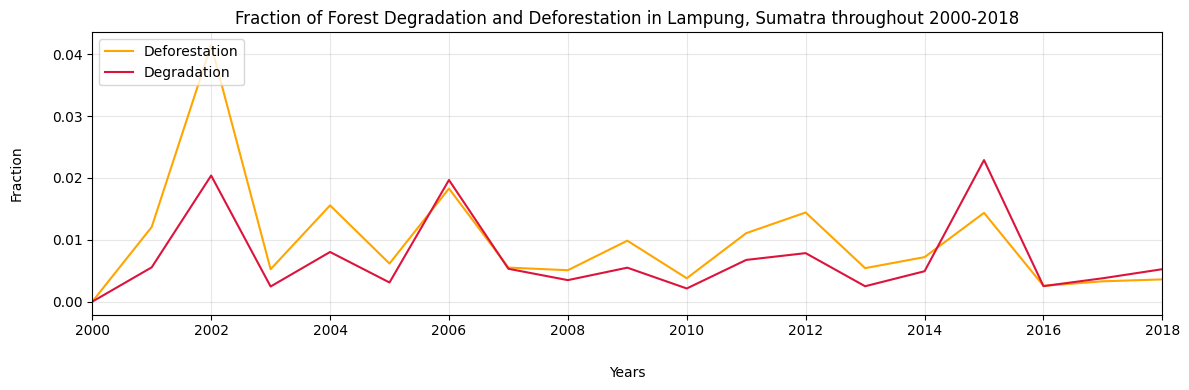

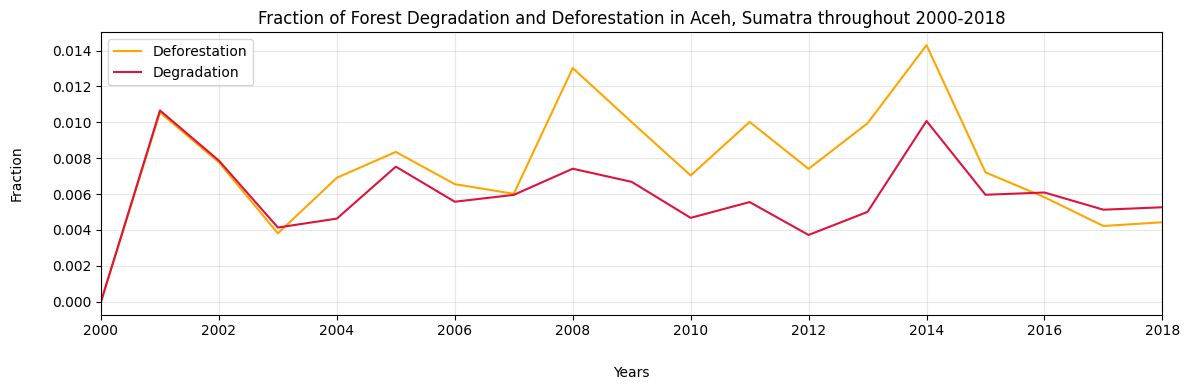

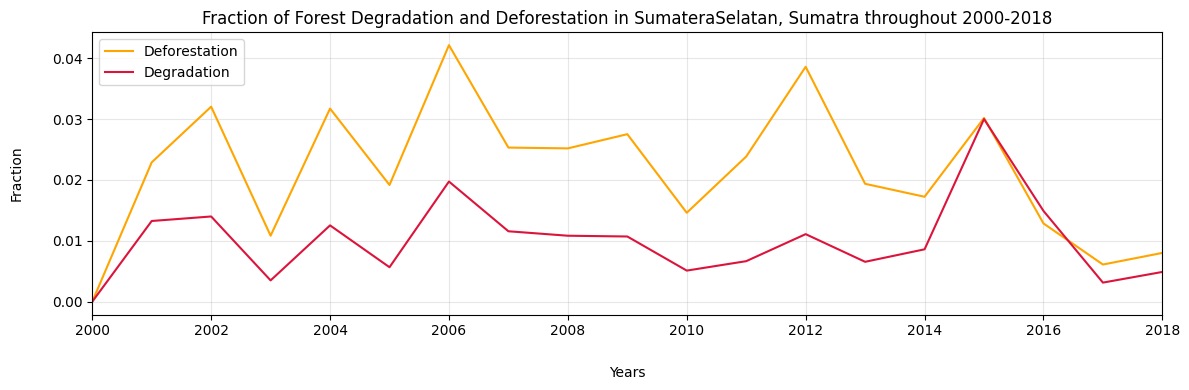

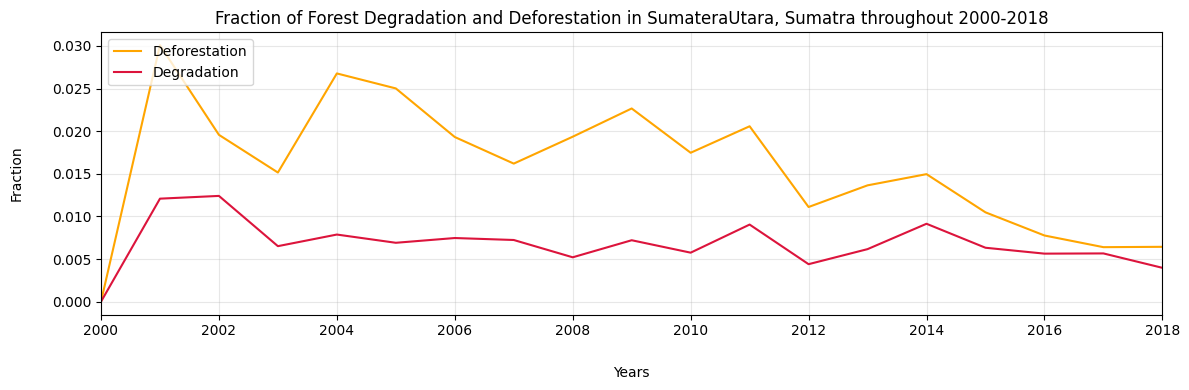

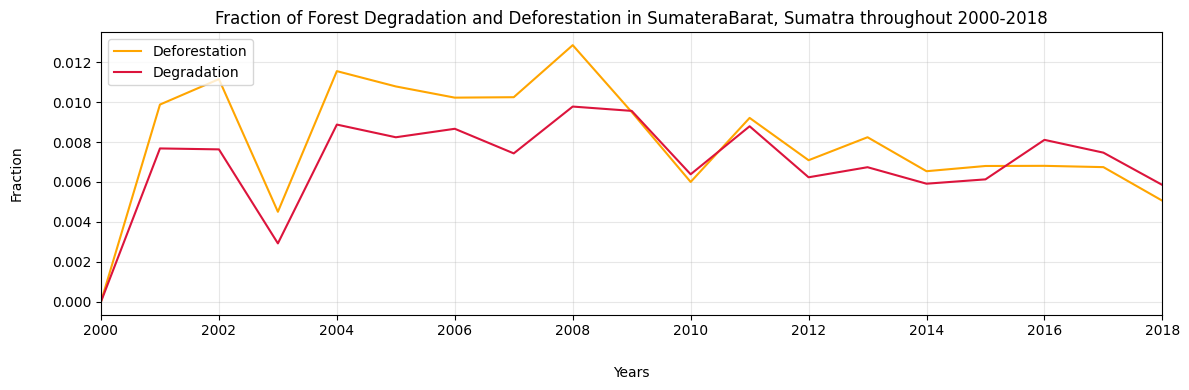

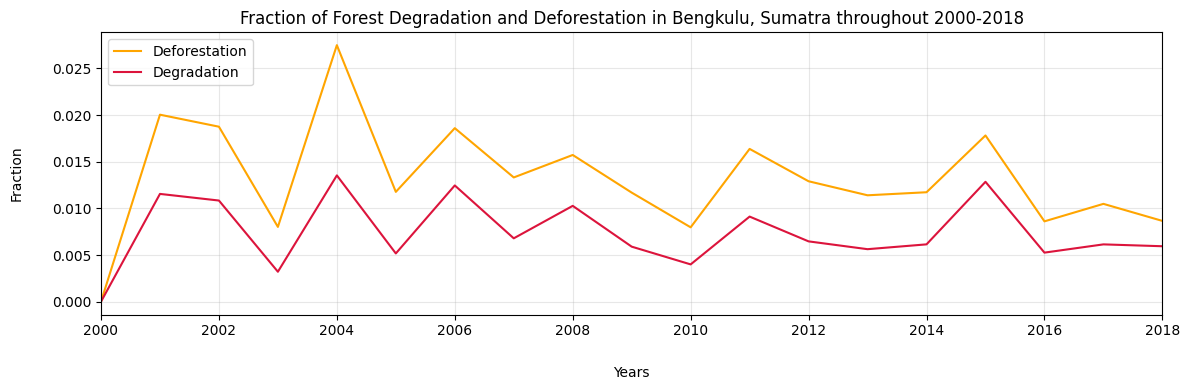

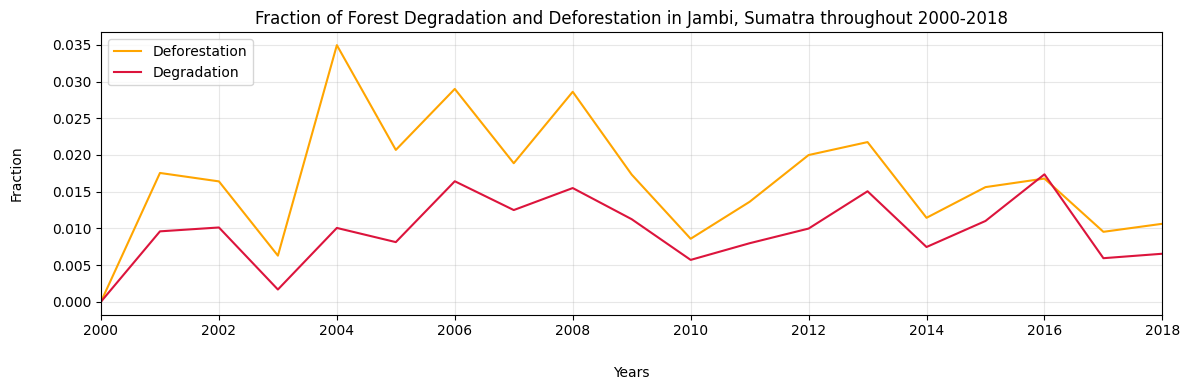

In [ ]:
# Graph depicting degradation, deforestation and remaining forest throughout the years
provinces = ["Riau", "Lampung", "Aceh", "SumateraSelatan", "SumateraUtara", "SumateraBarat", "Bengkulu", "Jambi"]

for prov in provinces:
  temp = deforest_prov_t[deforest_prov_t["province"] == prov]

  plt.plot(temp["year"], temp["defor_frac"], color = "orange", label = "Deforestation")
  plt.plot(temp["year"], temp["degr_frac"], color = "crimson", label = "Degradation")
  plt.title(f"Fraction of Forest Degradation and Deforestation in {prov}, Sumatra throughout 2000-2018")
  plt.xlabel("Years", labelpad = 20)
  plt.xlim(2000,2018)
  plt.ylabel("Fraction", labelpad = 20)
  plt.legend(loc="upper left")
  plt.tight_layout()
  plt.show()

In [ ]:
# Grouping by providence and year using standarization

deforest_prov_norm = data.groupby(["province", "year"])[["remaining_frac_baseline", "defor_frac", "degr_frac"]].mean().reset_index()
deforest_prov_norm

,province,year,remaining_frac_baseline,defor_frac,degr_frac
0,Aceh,2000,1.000000,0.000000,0.000000
1,Aceh,2001,0.989450,0.010550,0.010663
2,Aceh,2002,0.981686,0.007765,0.007863
3,Aceh,2003,0.977875,0.003810,0.004135
4,Aceh,2004,0.970964,0.006912,0.004632
...,...,...,...,...,...
147,SumateraUtara,2014,0.728190,0.014955,0.009137
148,SumateraUtara,2015,0.717714,0.010477,0.006325
149,SumateraUtara,2016,0.709952,0.007762,0.005633
150,SumateraUtara,2017,0.703559,0.006392,0.005659


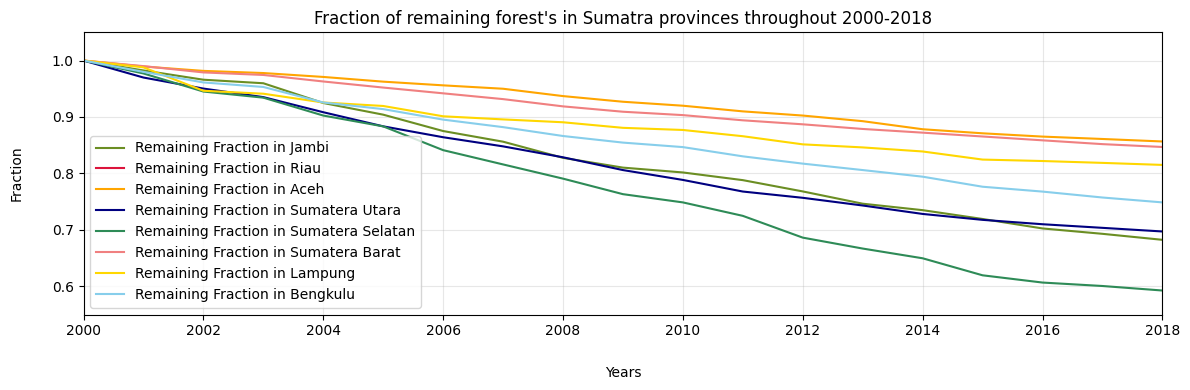

In [ ]:
plt.plot(deforest_prov_norm[deforest_prov_norm["province"] == "Jambi"]["year"], deforest_prov_norm[deforest_prov_norm["province"] == "Jambi"]["remaining_frac_baseline"], color = "olivedrab", label = "Remaining Fraction in Jambi")
plt.plot(deforest_prov_norm[deforest_prov_norm["province"] == "Riau"]["year"], color = "crimson", label = "Remaining Fraction in Riau")
plt.plot(deforest_prov_norm[deforest_prov_norm["province"] == "Aceh"]["year"], deforest_prov_norm[deforest_prov_norm["province"] == "Aceh"]["remaining_frac_baseline"], color = "orange", label = "Remaining Fraction in Aceh")
plt.plot(deforest_prov_norm[deforest_prov_norm["province"] == "SumateraUtara"]["year"], deforest_prov_norm[deforest_prov_norm["province"] == "SumateraUtara"]["remaining_frac_baseline"], color = "navy", label = "Remaining Fraction in Sumatera Utara")
plt.plot(deforest_prov_norm[deforest_prov_norm["province"] == "SumateraSelatan"]["year"], deforest_prov_norm[deforest_prov_norm["province"] == "SumateraSelatan"]["remaining_frac_baseline"], color = "seagreen", label = "Remaining Fraction in Sumatera Selatan")
plt.plot(deforest_prov_norm[deforest_prov_norm["province"] == "SumateraBarat"]["year"], deforest_prov_norm[deforest_prov_norm["province"] == "SumateraBarat"]["remaining_frac_baseline"], color = "lightcoral", label = "Remaining Fraction in Sumatera Barat")
plt.plot(deforest_prov_norm[deforest_prov_norm["province"] == "Lampung"]["year"], deforest_prov_norm[deforest_prov_norm["province"] == "Lampung"]["remaining_frac_baseline"], color = "gold", label = "Remaining Fraction in Lampung")
plt.plot(deforest_prov_norm[deforest_prov_norm["province"] == "Bengkulu"]["year"], deforest_prov_norm[deforest_prov_norm["province"] == "Bengkulu"]["remaining_frac_baseline"], color = "skyblue", label = "Remaining Fraction in Bengkulu")

plt.title(f"Fraction of remaining forest's in Sumatra provinces throughout 2000-2018")
plt.xlabel("Years", labelpad = 20)
plt.xlim(2000,2018)
plt.ylim(0.55, 1.05)
plt.ylabel("Fraction", labelpad = 20)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

df = deforest_prov_norm[deforest_prov_norm["province"] == "Jambi"]["degr_frac"]

In [ ]:
# Grouping by hex_id and year
deforest_hex = data.groupby(["hex_id", "year"])[['defor_frac', 'degr_frac', 'remaining_frac_baseline', 'remaining_frac_hex', 'remaining_forest_ha', 'nbr_r1_defor_frac', 'nbr_r2_defor_frac', 'nbr_r1_remaining_frac_baseline']].median().reset_index()
deforest_hex

,hex_id,year,defor_frac,degr_frac,remaining_frac_baseline,remaining_frac_hex,remaining_forest_ha,nbr_r1_defor_frac,nbr_r2_defor_frac,nbr_r1_remaining_frac_baseline
0,86642c96fffffff,2000,0.000000,0.000000,1.000000,0.464663,2009.95,0.000000,NaN,1.000000
1,86642c96fffffff,2001,0.032801,0.027606,0.967199,0.449421,1944.02,0.006728,NaN,0.993272
2,86642c96fffffff,2002,0.021762,0.024175,0.945437,0.439309,1900.28,0.008174,NaN,0.985098
3,86642c96fffffff,2003,0.001903,0.000973,0.943534,0.438425,1896.46,0.000895,NaN,0.984203
4,86642c96fffffff,2004,0.011296,0.007714,0.932238,0.433177,1873.75,0.004071,NaN,0.980132
...,...,...,...,...,...,...,...,...,...,...
165447,868cf6db7ffffff,2014,0.025313,0.006765,0.504889,0.177586,689.42,0.016244,0.019381,0.636175
165448,868cf6db7ffffff,2015,0.011539,0.005554,0.493351,0.173528,673.66,0.018627,0.019631,0.617548
165449,868cf6db7ffffff,2016,0.013483,0.004640,0.479867,0.168785,655.25,0.021773,0.013013,0.595775
165450,868cf6db7ffffff,2017,0.005961,0.002745,0.473906,0.166689,647.11,0.004125,0.004524,0.591649


In [ ]:
# Grouping by providence and hexagon regions
deforest_hex = data.copy()
deforest_hex = deforest_hex.groupby(["province", "hex_id", "lat", "lon", "hex_area_km2"])["remaining_frac_hex"].mean().reset_index()
deforest_hex

,province,hex_id,lat,lon,hex_area_km2,remaining_frac_hex
0,Aceh,86642c96fffffff,5.864320,95.333609,43.2561,0.418593
1,Aceh,86650825fffffff,4.326226,98.222230,42.8941,0.204493
2,Aceh,8665082cfffffff,4.435317,98.231158,42.9171,0.506858
3,Aceh,8665082efffffff,4.378315,98.258395,42.9026,0.638076
4,Aceh,866509007ffffff,3.981156,97.715918,42.8518,0.988877
...,...,...,...,...,...,...
8703,SumateraUtara,868cdab5fffffff,-0.358996,98.406361,41.4390,0.875435
8704,SumateraUtara,868cdab67ffffff,-0.470184,98.459966,41.3904,0.959868
8705,SumateraUtara,868cdab6fffffff,-0.465589,98.397507,41.3977,0.929491
8706,SumateraUtara,868cdab77ffffff,-0.419199,98.495633,41.4075,0.605938


In [ ]:
import plotly.express as px

# Create the map trace
fig = px.scatter_map(
    deforest_hex,
    lat="lat",
    lon="lon",
    hover_name="province",
    hover_data = ["hex_id", "remaining_frac_hex"],
    size="hex_area_km2",
    color="province",
    zoom=5,
    map_style = "satellite",
    title = "Remaining Forest Fraction of Hexagons in Sumatra Provinces",
    width = 1000,
    height = 1000
)

fig.show()